In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [6]:
df_train = pd.read_csv('../data/processed/train_data.csv')
df_test = pd.read_csv('../data/processed/test_data.csv')

In [7]:
print("Train set shape:", df_train.shape)
print("Test set shape:", df_test.shape)

Train set shape: (403764, 18)
Test set shape: (16992, 18)


In [8]:
df_train.head()

,year,month,day,hour,PM2.5,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,PM2.5_shift1,PM10_shift1,SO2_shift1,NO2_shift1,CO_shift1,O3_shift1
0,2013,3,1,1,8.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,4.0,4.0,4.0,7.0,300.0,77.0
1,2013,3,1,2,7.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,8.0,8.0,4.0,7.0,300.0,77.0
2,2013,3,1,3,6.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,7.0,7.0,5.0,10.0,300.0,73.0
3,2013,3,1,4,3.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,6.0,6.0,11.0,11.0,300.0,72.0
4,2013,3,1,5,5.0,-2.2,1025.6,-19.6,0.0,N,3.7,Aotizhongxin,3.0,3.0,12.0,12.0,300.0,72.0


In [9]:
print('WD len unique =',len(df_train['wd'].unique()))
print('Station len unique =',len(df_test['station'].unique()))

WD len unique = 16
Station len unique = 12


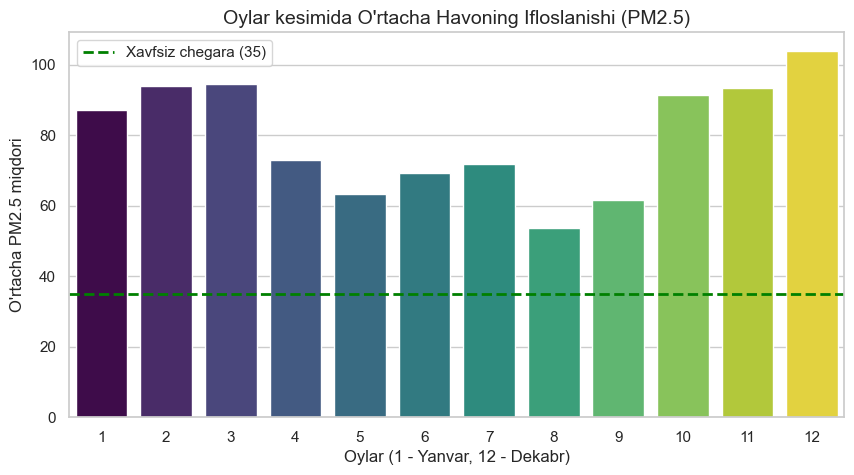

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Oylar bo'yicha PM2.5 ning o'rtacha qiymatini hisoblaymiz
oylik_ifloslanish = df_train.groupby('month')['PM2.5'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(x='month', y='PM2.5', data=oylik_ifloslanish, palette='viridis',legend=False,hue='month')

plt.title("Oylar kesimida O'rtacha Havoning Ifloslanishi (PM2.5)", fontsize=14)
plt.xlabel("Oylar (1 - Yanvar, 12 - Dekabr)", fontsize=12)
plt.ylabel("O'rtacha PM2.5 miqdori", fontsize=12)

# Xavfsiz chegara chizig'i (JSST me'yori taxminan 35 mk/g)
plt.axhline(35, color='green', linestyle='--', linewidth=2, label="Xavfsiz chegara (35)")
plt.legend()
plt.show()

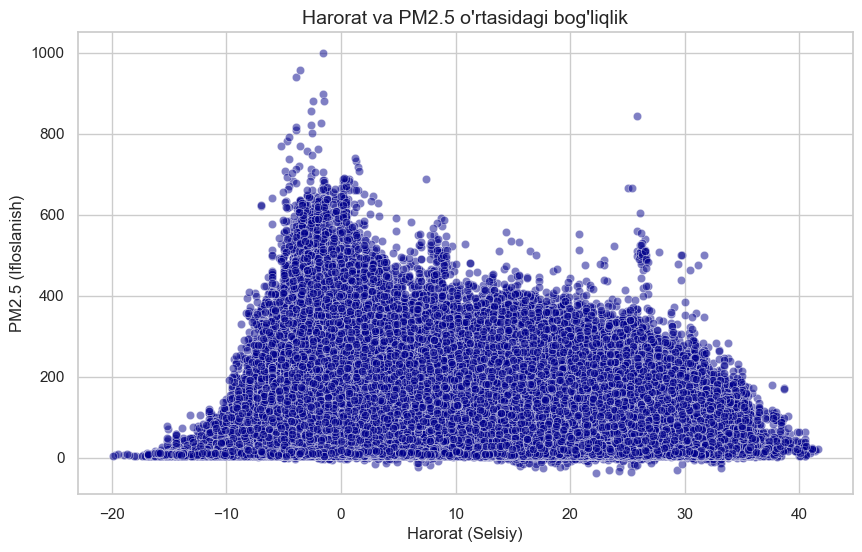

In [16]:
plt.figure(figsize=(10, 6))

# Harorat (TEMP) va PM2.5 ni solishtiramiz. 
# Nuqtalar juda ko'p bo'lgani uchun ularni kichik va shaffof (alpha=0.1) qilamiz
sns.scatterplot(x='TEMP', y='PM2.5', data=df_train, alpha=0.5, color="darkblue")

plt.title("Harorat va PM2.5 o'rtasidagi bog'liqlik", fontsize=14)
plt.xlabel("Harorat (Selsiy)", fontsize=12)
plt.ylabel("PM2.5 (Ifloslanish)", fontsize=12)

plt.show()

In [33]:
df_train.groupby('station')['PM2.5'].count()

station
Aotizhongxin     33647
Changping        33647
Dingling         33647
Dongsi           33647
Guanyuan         33647
Gucheng          33647
Huairou          33647
Nongzhanguan     33647
Shunyi           33647
Tiantan          33647
Wanliu           33647
Wanshouxigong    33647
Name: PM2.5, dtype: int64

In [35]:
df_train['year'].value_counts()

year
2016    105408
2014    105120
2015    105120
2013     88116
Name: count, dtype: int64